In [2]:
''' step 1 : problem statement '''
'''
    we are given 8 features and a target col , we need to find 
    if a person has diabetics or not 
    1 - diabetics    0 - no diabetics
'''

'\n    we are given 8 features and a target col , we need to find \n    if a person has diabetics or not \n    1 - diabetics    0 - no diabetics\n'

In [3]:
''' step 2 : Data Collection '''

import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.expand_frame_repr", False)

df = pd.read_csv("../dataset/diabetes.csv")

print("the top 5 records are : ")
print(df.head())
print("\n\n the shape of the dataset is : ")
print(df.shape)
print("\n\n the column names are : ")
print(df.columns)

the top 5 records are : 
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction  Age  Outcome
0            6      148             72             35        0  33.6                     0.627   50        1
1            1       85             66             29        0  26.6                     0.351   31        0
2            8      183             64              0        0  23.3                     0.672   32        1
3            1       89             66             23       94  28.1                     0.167   21        0
4            0      137             40             35      168  43.1                     2.288   33        1


 the shape of the dataset is : 
(768, 9)


 the column names are : 
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'], dtype='str')


In [4]:

''' step 3 : Train Test Split '''

from sklearn.model_selection import train_test_split

# seperating output form the features 
x = df.drop("Outcome",axis = 1)
y = df["Outcome"]


print(x.head())
print("\n")
print(y.head())

x_train , x_test , y_train , y_test = train_test_split(
    x,y,test_size = 0.2 , random_state=69,
    stratify = y
)

print(x_train.shape)
print(x_test.shape)


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction  Age
0            6      148             72             35        0  33.6                     0.627   50
1            1       85             66             29        0  26.6                     0.351   31
2            8      183             64              0        0  23.3                     0.672   32
3            1       89             66             23       94  28.1                     0.167   21
4            0      137             40             35      168  43.1                     2.288   33


0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64
(614, 8)
(154, 8)


In [5]:
''' step 4 : EDA '''

from IPython.display import display

# understanding your data before modeling it

df.info()
print()

display(df.describe().T)

display((df == 0).sum().to_frame("Zero_Count"))

display(df["Outcome"].value_counts().to_frame("Count"))

display(df.corr(numeric_only=True)[["Outcome"]].sort_values("Outcome", ascending=False))


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB



,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


,Zero_Count
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


,Count
Outcome,
0,500
1,268


,Outcome
Outcome,1.000000
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


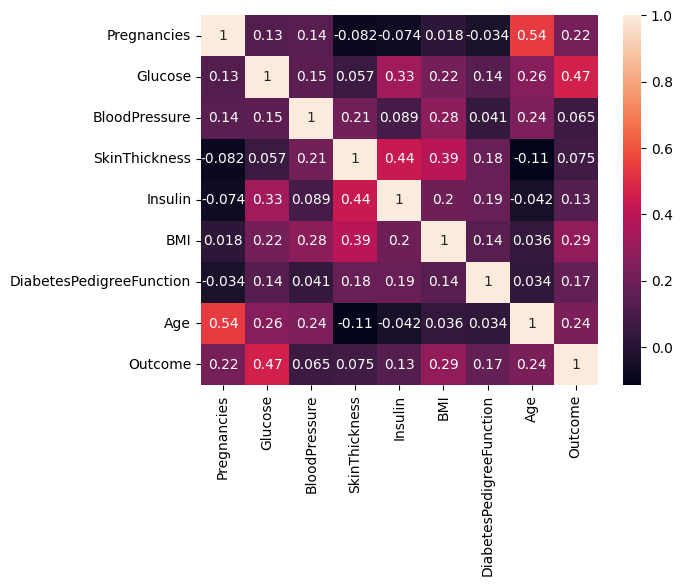

In [6]:
''' visualization of corelation '''
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True)
plt.show()

In [7]:
''' step 5 : preprocessing and feature engg '''

# we are not doing any Feature engg here because we have all the features we want

''' handling missing values '''

import numpy as np
from IPython.display import display

# columns where 0 is invalid and should be treated as missing
zero_col = ["Glucose", "BloodPressure", "SkinThickness", "BMI"]
# zero_col = ["Glucose", "BloodPressure", "BMI"]
# zero_col = ["Glucose", "BloodPressure", "SkinThickness", "BMI", "Insulin"]

# replace invalid 0 values with NaN
for col in zero_col:
    x_train[col] = x_train[col].replace(0, np.nan)
    x_test[col] = x_test[col].replace(0, np.nan)

print("Before imputation:")
display(x_train.head())
display(x_test.head())

# fill missing values with train median
for col in zero_col:
    median = x_train[col].median()
    x_train[col] = x_train[col].fillna(median)
    x_test[col] = x_test[col].fillna(median)

print("After imputation:")
display(x_train.head())
display(x_test.head())

print("Missing values count (train):")
display(x_train[zero_col].isna().sum().to_frame("Missing_Count"))

print("Missing values count (test):")
display(x_test[zero_col].isna().sum().to_frame("Missing_Count"))


Before imputation:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
671,1,99.0,58.0,10.0,0,25.4,0.551,21
282,7,133.0,88.0,15.0,155,32.4,0.262,37
416,1,97.0,68.0,21.0,0,27.2,1.095,22
151,4,114.0,65.0,NaN,0,21.9,0.432,37
232,1,79.0,80.0,25.0,37,25.4,0.583,22


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
421,2,94.0,68.0,18.0,76,26.0,0.561,21
87,2,100.0,68.0,25.0,71,38.5,0.324,26
178,5,143.0,78.0,NaN,0,45.0,0.190,47
333,12,106.0,80.0,NaN,0,23.6,0.137,44
229,0,117.0,80.0,31.0,53,45.2,0.089,24


After imputation:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
671,1,99.0,58.0,10.0,0,25.4,0.551,21
282,7,133.0,88.0,15.0,155,32.4,0.262,37
416,1,97.0,68.0,21.0,0,27.2,1.095,22
151,4,114.0,65.0,30.0,0,21.9,0.432,37
232,1,79.0,80.0,25.0,37,25.4,0.583,22


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
421,2,94.0,68.0,18.0,76,26.0,0.561,21
87,2,100.0,68.0,25.0,71,38.5,0.324,26
178,5,143.0,78.0,30.0,0,45.0,0.190,47
333,12,106.0,80.0,30.0,0,23.6,0.137,44
229,0,117.0,80.0,31.0,53,45.2,0.089,24


Missing values count (train):


,Missing_Count
Glucose,0
BloodPressure,0
SkinThickness,0
BMI,0


Missing values count (test):


,Missing_Count
Glucose,0
BloodPressure,0
SkinThickness,0
BMI,0


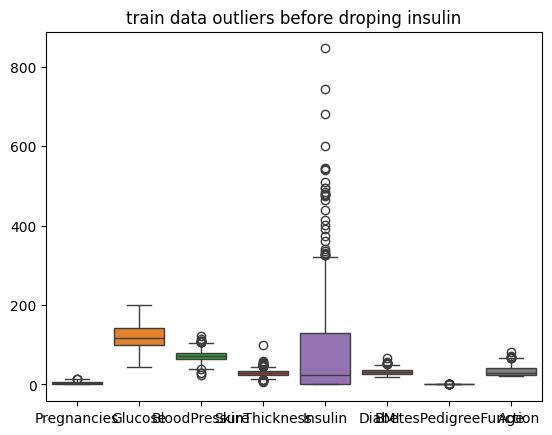

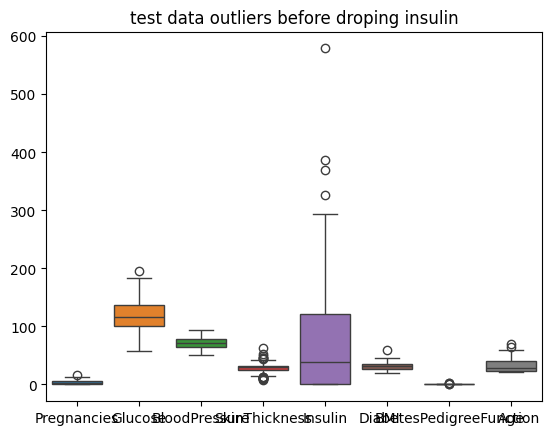

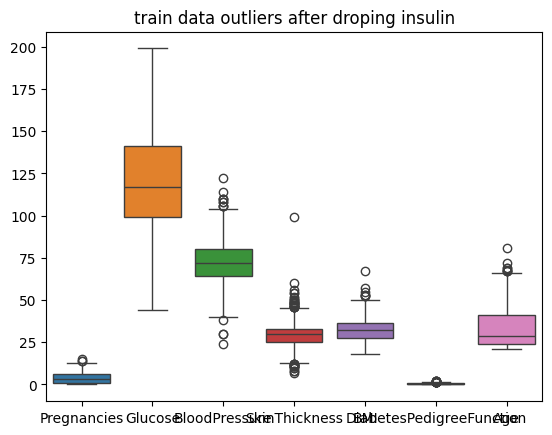

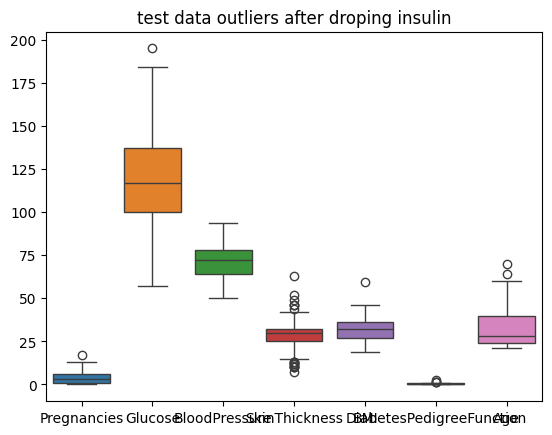

In [8]:

''' outlier handling if anything is present '''

import seaborn as sns
import matplotlib.pyplot as plt

# checking if outliers are present in train data 
sns.boxplot(data=x_train)
plt.title("train data outliers before droping insulin")
plt.show()

# checking if outliers are present in test data
sns.boxplot(data=x_test)
plt.title("test data outliers before droping insulin")
plt.show()

# after checking came to a conclusion to drp insulin col 
x_train = x_train.drop(columns=["Insulin"], errors="ignore")
x_test  = x_test.drop(columns=["Insulin"], errors="ignore")

# # dropping skin thickness also (right now we are not droping)
# x_train = x_train.drop(columns=["SkinThickness"], errors="ignore")
# x_test  = x_test.drop(columns=["SkinThickness"], errors="ignore")

# checking if outliers are present in train data after dropping insulin
sns.boxplot(data=x_train)
plt.title("train data outliers after droping insulin")
plt.show()

# checking if outliers are present in test data after dropping insulin 
sns.boxplot(data=x_test)
plt.title("test data outliers after droping insulin")
plt.show()


In [9]:

''' now lets count the number of outliers using IQR '''
import pandas as pd

def get_iqr_bounds(train_df):
    num_cols = train_df.select_dtypes(include="number").columns
    bounds = {}
    for col in num_cols:
        q1 = train_df[col].quantile(0.25)
        q3 = train_df[col].quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        bounds[col] = (low, high)
    return bounds

def outlier_count_with_bounds(df, bounds):
    rows = []
    for col, (low, high) in bounds.items():
        count = ((df[col] < low) | (df[col] > high)).sum()
        rows.append([col, count, low, high])
    return pd.DataFrame(rows, columns=["Feature", "Outlier_Count", "Lower_Bound", "Upper_Bound"])

# compute only from train
iqr_bounds = get_iqr_bounds(x_train)

# use same bounds for both
train_outliers = outlier_count_with_bounds(x_train, iqr_bounds)
test_outliers  = outlier_count_with_bounds(x_test, iqr_bounds)

display(train_outliers.sort_values("Outlier_Count", ascending=False))
display(test_outliers.sort_values("Outlier_Count", ascending=False))


,Feature,Outlier_Count,Lower_Bound,Upper_Bound
3,SkinThickness,39,13.000,45.000
5,DiabetesPedigreeFunction,26,-0.334,1.208
2,BloodPressure,14,40.000,104.000
6,Age,8,-1.500,66.500
4,BMI,7,14.100,50.100
0,Pregnancies,3,-6.500,13.500
1,Glucose,0,36.000,204.000


,Feature,Outlier_Count,Lower_Bound,Upper_Bound
3,SkinThickness,14,13.000,45.000
5,DiabetesPedigreeFunction,3,-0.334,1.208
0,Pregnancies,1,-6.500,13.500
4,BMI,1,14.100,50.100
6,Age,1,-1.500,66.500
2,BloodPressure,0,40.000,104.000
1,Glucose,0,36.000,204.000


,Feature,Outlier_Count,Lower_Bound,Upper_Bound
0,Pregnancies,0,-6.500,13.500
1,Glucose,0,36.000,204.000
2,BloodPressure,0,40.000,104.000
3,SkinThickness,0,13.000,45.000
4,BMI,0,14.100,50.100
5,DiabetesPedigreeFunction,0,-0.334,1.208
6,Age,0,-1.500,66.500


,Feature,Outlier_Count,Lower_Bound,Upper_Bound
0,Pregnancies,0,-6.500,13.500
1,Glucose,0,36.000,204.000
2,BloodPressure,0,40.000,104.000
3,SkinThickness,0,13.000,45.000
4,BMI,0,14.100,50.100
5,DiabetesPedigreeFunction,0,-0.334,1.208
6,Age,0,-1.500,66.500


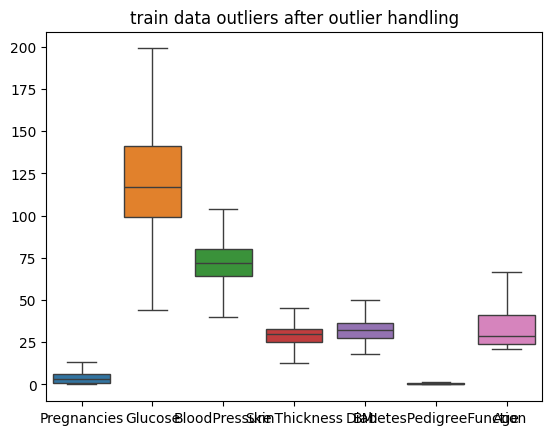

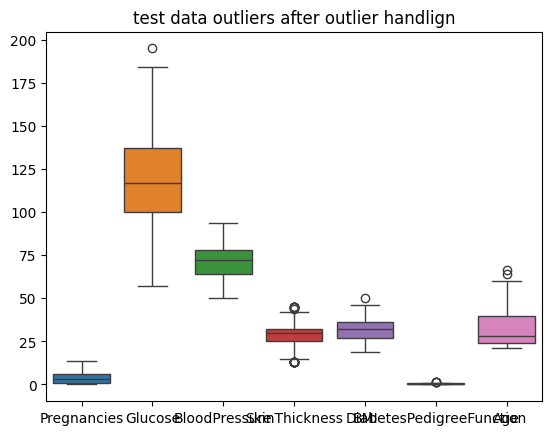

In [10]:
''' ok now lets handle the outliers '''

# cap using train-derived bounds
for col, (low, high) in iqr_bounds.items():
    x_train[col] = x_train[col].clip(lower=low, upper=high)
    x_test[col] = x_test[col].clip(lower=low, upper=high)

# now check again thenumber of outliers 
train_outliers = outlier_count_with_bounds(x_train, iqr_bounds)
test_outliers  = outlier_count_with_bounds(x_test, iqr_bounds)

display(train_outliers.sort_values("Outlier_Count", ascending=False))
display(test_outliers.sort_values("Outlier_Count", ascending=False))

# checking if outliers are present in train data after outlier handling
sns.boxplot(data=x_train)
plt.title("train data outliers after outlier handling")
plt.show()

# checking if outliers are present in test data ater outlier handling
sns.boxplot(data=x_test)
plt.title("test data outliers after outlier handlign")
plt.show()

In [11]:

''' standardization '''

from sklearn.preprocessing import StandardScaler
from IPython.display import display

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)   # fit only on train
x_test_scaled  = scaler.transform(x_test)        # transform test

# convert back to DataFrame
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns, index=x_train.index)
x_test_scaled  = pd.DataFrame(x_test_scaled, columns=x_test.columns, index=x_test.index)

display(x_train_scaled.head())
display(x_test_scaled.head())


,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
671,-0.845459,-0.744104,-1.197701,-2.102273,-1.061575,0.290631,-1.047773
282,0.948190,0.358844,1.267013,-1.845832,-0.009789,-0.698310,0.296003
416,-0.845459,-0.808983,-0.376130,-1.076509,-0.791116,2.152168,-0.963787
151,0.051365,-0.257509,-0.622601,0.077475,-1.587469,-0.116580,0.296003
232,-0.845459,-1.392896,0.609756,-0.563627,-1.061575,0.400133,-0.963787


,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
421,-0.546518,-0.906302,-0.376130,-1.461170,-0.971422,0.324850,-1.047773
87,-0.546518,-0.711664,-0.376130,-0.563627,0.906768,-0.486150,-0.627843
178,0.350307,0.683240,0.445441,0.077475,1.883427,-0.944690,1.135863
333,2.442897,-0.517026,0.609756,0.077475,-1.332035,-1.126053,0.883905
229,-1.144400,-0.160190,0.609756,0.205696,1.913479,-1.290306,-0.795815


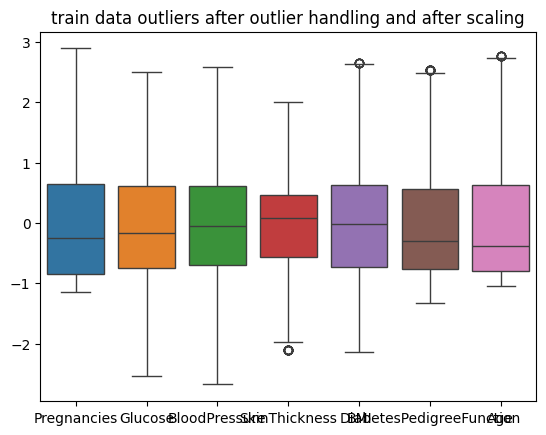

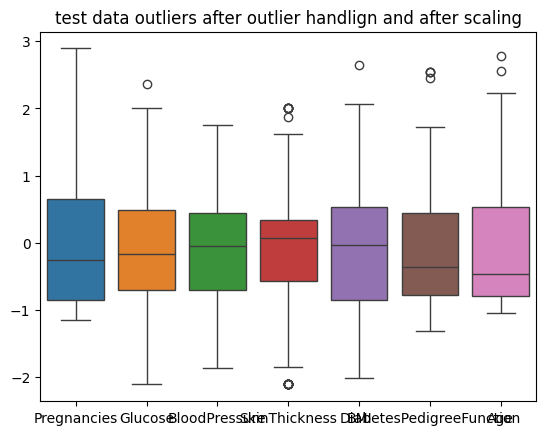

In [12]:
sns.boxplot(data=x_train_scaled)
plt.title("train data outliers after outlier handling and after scaling")
plt.show()

# checking if outliers are present in test data ater outlier handling
sns.boxplot(data=x_test_scaled)
plt.title("test data outliers after outlier handlign and after scaling")
plt.show()

In [13]:

''' check the number of outliers after standard scaling  '''
import pandas as pd

def get_iqr_bounds(train_df):
    num_cols = train_df.select_dtypes(include="number").columns
    bounds = {}
    for col in num_cols:
        q1 = train_df[col].quantile(0.25)
        q3 = train_df[col].quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        bounds[col] = (low, high)
    return bounds

def outlier_count_with_bounds(df, bounds):
    rows = []
    for col, (low, high) in bounds.items():
        count = ((df[col] < low) | (df[col] > high)).sum()
        rows.append([col, count, low, high])
    return pd.DataFrame(rows, columns=["Feature", "Outlier_Count", "Lower_Bound", "Upper_Bound"])

# compute only from train
iqr_bounds = get_iqr_bounds(x_train_scaled)

# use same bounds for both
train_outliers = outlier_count_with_bounds(x_train_scaled, iqr_bounds)
test_outliers  = outlier_count_with_bounds(x_test_scaled, iqr_bounds)

display(train_outliers.sort_values("Outlier_Count", ascending=False))
display(test_outliers.sort_values("Outlier_Count", ascending=False))


,Feature,Outlier_Count,Lower_Bound,Upper_Bound
5,DiabetesPedigreeFunction,26,-2.737788,2.538847
3,SkinThickness,22,-2.102273,2.000782
6,Age,8,-2.937459,2.773590
4,BMI,7,-2.759460,2.649729
2,BloodPressure,0,-2.676529,2.581527
0,Pregnancies,0,-3.087520,2.891309
1,Glucose,0,-2.787800,2.662057


,Feature,Outlier_Count,Lower_Bound,Upper_Bound
3,SkinThickness,11,-2.102273,2.000782
5,DiabetesPedigreeFunction,3,-2.737788,2.538847
4,BMI,1,-2.759460,2.649729
6,Age,1,-2.937459,2.773590
2,BloodPressure,0,-2.676529,2.581527
0,Pregnancies,0,-3.087520,2.891309
1,Glucose,0,-2.787800,2.662057


In [14]:
'''renameing the scaled data as x_train and x_test just for easier naming'''

x_train = x_train_scaled
x_test = x_test_scaled

display(x_train.head())
display(x_test.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
671,-0.845459,-0.744104,-1.197701,-2.102273,-1.061575,0.290631,-1.047773
282,0.948190,0.358844,1.267013,-1.845832,-0.009789,-0.698310,0.296003
416,-0.845459,-0.808983,-0.376130,-1.076509,-0.791116,2.152168,-0.963787
151,0.051365,-0.257509,-0.622601,0.077475,-1.587469,-0.116580,0.296003
232,-0.845459,-1.392896,0.609756,-0.563627,-1.061575,0.400133,-0.963787


,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
421,-0.546518,-0.906302,-0.376130,-1.461170,-0.971422,0.324850,-1.047773
87,-0.546518,-0.711664,-0.376130,-0.563627,0.906768,-0.486150,-0.627843
178,0.350307,0.683240,0.445441,0.077475,1.883427,-0.944690,1.135863
333,2.442897,-0.517026,0.609756,0.077475,-1.332035,-1.126053,0.883905
229,-1.144400,-0.160190,0.609756,0.205696,1.913479,-1.290306,-0.795815


In [15]:
''' step 6 : baseline model selection '''

''' out of all baseline models we need to select the best one so we will train and validate 
all the baseline models on the training data and select the best one based on validation metrics 
'''

''' for that to happen first we will divide the scaled training data into training
 data and validation data
'''

from sklearn.model_selection import train_test_split

x_tr_bms, x_val_bms , y_tr_bms , y_val_bms = train_test_split(
    x_train , y_train, test_size = 0.2 ,
    random_state = 69,
    stratify = y_train
)

display(x_tr_bms.head())
display(y_tr_bms.head())



,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
431,-0.247576,-1.068500,0.116813,-1.717611,-0.310299,0.290631,0.379989
289,0.350307,-0.452147,-0.047501,1.744341,0.546156,-0.694888,-0.039941
476,-0.546518,-0.549466,0.609756,2.000782,0.185543,0.838142,-0.375885
548,-0.845459,1.364472,0.774070,1.744341,0.050313,-0.427977,1.387821
696,-0.247576,1.526670,0.116813,-1.332950,-0.385427,-0.677779,-0.207913


431    0
289    0
476    1
548    0
696    1
Name: Outcome, dtype: int64

In [16]:

from imblearn.over_sampling import SMOTE

''' due to class imbalance lets smote it '''

smote = SMOTE(random_state=69)
x_tr_bms_sm, y_tr_bms_sm = smote.fit_resample(x_tr_bms, y_tr_bms)

print("Before SMOTE:", y_tr_bms.value_counts().to_dict())
print("After  SMOTE:", y_tr_bms_sm.value_counts().to_dict())


Before SMOTE: {0: 320, 1: 171}
After  SMOTE: {0: 320, 1: 320}


In [17]:
''' now we just hit and trail 
    we calcualte the validation metrics for different baseline models and select the best one 
'''

'''baseline_model_1 : logistic regression '''
''' 
    logistic regression is best here beacuse it is good for problem statements with binary classifications
'''

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score , f1_score , roc_auc_score 
from sklearn.metrics import confusion_matrix, classification_report

''' train model '''

lr = LogisticRegression(max_iter=1000, random_state=69)
lr.fit(x_tr_bms_sm,y_tr_bms_sm)

''' validation of the validation data using the trained model '''

y_val_prob_lr = lr.predict_proba(x_val_bms)[:, 1]
threshold = 0.5
y_val_pred_lr = (y_val_prob_lr >= threshold).astype(int)


# print(y_val_pred_lr) # this gives the final class 0 or 1
# print(list(y_val_bms))
# print(y_val_prob_lr) # this gives the prob then by seeing prob prediction happens

'''metrics'''
print("Logistic regression")
print("Accuracy :", round(accuracy_score(y_val_bms, y_val_pred_lr), 4))
print("Precision:", round(precision_score(y_val_bms, y_val_pred_lr), 4))
print("Recall   :", round(recall_score(y_val_bms, y_val_pred_lr), 4))
print("F1-score :", round(f1_score(y_val_bms, y_val_pred_lr), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val_bms, y_val_prob_lr), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_bms, y_val_pred_lr))

print("\nClassification Report:")
print(classification_report(y_val_bms, y_val_pred_lr))

Logistic regression
Accuracy : 0.7561
Precision: 0.6226
Recall   : 0.7674
F1-score : 0.6875
ROC-AUC  : 0.8581

Confusion Matrix:
[[60 20]
 [10 33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80        80
           1       0.62      0.77      0.69        43

    accuracy                           0.76       123
   macro avg       0.74      0.76      0.74       123
weighted avg       0.78      0.76      0.76       123



In [18]:
'''baseline_model_2 : decision tree'''

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

# train decision tree on the same SMOTE-balanced training data
dt = DecisionTreeClassifier(random_state=69)
dt.fit(x_tr_bms_sm, y_tr_bms_sm)

# validate on untouched validation data
y_val_pred_dt = dt.predict(x_val_bms)
y_val_prob_dt = dt.predict_proba(x_val_bms)[:, 1]

# metrics
print("decisionTreeClassifier")
print("Accuracy :", round(accuracy_score(y_val_bms, y_val_pred_dt), 4))
print("Precision:", round(precision_score(y_val_bms, y_val_pred_dt), 4))
print("Recall   :", round(recall_score(y_val_bms, y_val_pred_dt), 4))
print("F1-score :", round(f1_score(y_val_bms, y_val_pred_dt), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val_bms, y_val_prob_dt), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_bms, y_val_pred_dt))

print("\nClassification Report:")
print(classification_report(y_val_bms, y_val_pred_dt))


decisionTreeClassifier
Accuracy : 0.748
Precision: 0.6364
Recall   : 0.6512
F1-score : 0.6437
ROC-AUC  : 0.7256

Confusion Matrix:
[[64 16]
 [15 28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        80
           1       0.64      0.65      0.64        43

    accuracy                           0.75       123
   macro avg       0.72      0.73      0.72       123
weighted avg       0.75      0.75      0.75       123



In [19]:
'''baseline_model_3 : random forest '''

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

# train random forest on the same SMOTE-balanced training data
rf = RandomForestClassifier(random_state=69)
rf.fit(x_tr_bms_sm, y_tr_bms_sm)

# validate on untouched validation data
y_val_pred_rf = rf.predict(x_val_bms)
y_val_prob_rf = rf.predict_proba(x_val_bms)[:, 1]

# metrics
print("RandomForestClassifier")
print("Accuracy :", round(accuracy_score(y_val_bms, y_val_pred_rf), 4))
print("Precision:", round(precision_score(y_val_bms, y_val_pred_rf), 4))
print("Recall   :", round(recall_score(y_val_bms, y_val_pred_rf), 4))
print("F1-score :", round(f1_score(y_val_bms, y_val_pred_rf), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val_bms, y_val_prob_rf), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_bms, y_val_pred_rf))

print("\nClassification Report:")
print(classification_report(y_val_bms, y_val_pred_rf))


RandomForestClassifier
Accuracy : 0.7805
Precision: 0.6818
Recall   : 0.6977
F1-score : 0.6897
ROC-AUC  : 0.8615

Confusion Matrix:
[[66 14]
 [13 30]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83        80
           1       0.68      0.70      0.69        43

    accuracy                           0.78       123
   macro avg       0.76      0.76      0.76       123
weighted avg       0.78      0.78      0.78       123



In [20]:
'''baseline_model_4 : xgboost'''

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

# train xgboost on same SMOTE-balanced training data
xgb = XGBClassifier(
    random_state=69,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss"
)

xgb.fit(x_tr_bms_sm, y_tr_bms_sm)

# validate on untouched validation data
y_val_pred_xgb = xgb.predict(x_val_bms)
y_val_prob_xgb = xgb.predict_proba(x_val_bms)[:, 1]

# metrics
print("XGBoostClassifier")
print("Accuracy :", round(accuracy_score(y_val_bms, y_val_pred_xgb), 4))
print("Precision:", round(precision_score(y_val_bms, y_val_pred_xgb), 4))
print("Recall   :", round(recall_score(y_val_bms, y_val_pred_xgb), 4))
print("F1-score :", round(f1_score(y_val_bms, y_val_pred_xgb), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val_bms, y_val_prob_xgb), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_bms, y_val_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_val_bms, y_val_pred_xgb))


XGBoostClassifier
Accuracy : 0.7724
Precision: 0.6531
Recall   : 0.7442
F1-score : 0.6957
ROC-AUC  : 0.8384

Confusion Matrix:
[[63 17]
 [11 32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.79      0.82        80
           1       0.65      0.74      0.70        43

    accuracy                           0.77       123
   macro avg       0.75      0.77      0.76       123
weighted avg       0.78      0.77      0.78       123



In [21]:
''' after everything we selected to go ahead with logistic regression '''

''' step 7 : k fold cv and hyperparameters tuning '''

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV

pipe = Pipeline([
    ("smote", SMOTE(random_state=69)),
    ("lr", LogisticRegression(max_iter=2000, random_state=69))
])

param_grid = {
    # "lr__threshold":[0.4,0.45,0.45], # remember threshold is not a hyper parameter 
    "lr__C": [0.01, 0.1, 1,2],
    "lr__solver": ["lbfgs", "liblinear"],
    "lr__class_weight": [None, "balanced"],
    "lr__max_iter": [1000, 2000, 3000]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",   # or "f1" or recall based on your priority
    cv=cv,
    n_jobs=-1
)

grid.fit(x_train, y_train)   # use training set only
print("Best Params:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))
best_model = grid.best_estimator_


Best Params: {'lr__C': 2, 'lr__class_weight': None, 'lr__max_iter': 1000, 'lr__solver': 'lbfgs'}
Best CV accuracy: 0.7394


In [22]:
''' step 8 and 9 : final training and final testing '''

# Train final Logistic Regression model on full training data using best hyperparameters
# (best_model came from GridSearchCV with SMOTE + LR pipeline)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

# 1) Refit on full training data (optional but explicit)
best_model.fit(x_train, y_train)

# 2) Predict on untouched test data
y_test_pred = best_model.predict(x_test)
y_test_prob = best_model.predict_proba(x_test)[:, 1]

# 3) Final test metrics
print("Final Test Metrics (Tuned LR + SMOTE)")
print("Accuracy :", round(accuracy_score(y_test, y_test_pred), 4))
print("Precision:", round(precision_score(y_test, y_test_pred), 4))
print("Recall   :", round(recall_score(y_test, y_test_pred), 4))
print("F1-score :", round(f1_score(y_test, y_test_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_test_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


Final Test Metrics (Tuned LR + SMOTE)
Accuracy : 0.8182
Precision: 0.7407
Recall   : 0.7407
F1-score : 0.7407
ROC-AUC  : 0.8846

Confusion Matrix:
[[86 14]
 [14 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       100
           1       0.74      0.74      0.74        54

    accuracy                           0.82       154
   macro avg       0.80      0.80      0.80       154
weighted avg       0.82      0.82      0.82       154



In [23]:
# it is giving bad results 

# ''' now lets take xgboost as out basline model'''

# ''' step 7 (xgboost): k-fold cv + hyperparameter tuning '''

# from xgboost import XGBClassifier
# from sklearn.model_selection import StratifiedKFold, GridSearchCV
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# from sklearn.metrics import confusion_matrix, classification_report

# # xgboost model
# xgb = XGBClassifier(
#     random_state=69,
#     eval_metric="logloss",
#     use_label_encoder=False
# )

# # hyperparameter grid
# param_grid_xgb = {
#     "n_estimators": [100, 200, 300],
#     "learning_rate": [0.01, 0.05, 0.1],
#     "max_depth": [3, 4, 5],
#     "subsample": [0.8, 0.9, 1.0],
#     "colsample_bytree": [0.8, 0.9, 1.0]
# }

# # k-fold setup
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)

# # grid search
# grid_xgb = GridSearchCV(
#     estimator=xgb,
#     param_grid=param_grid_xgb,
#     scoring="recall",   # use "f1" or "accuracy" if you want
#     cv=cv,
#     n_jobs=-1
# )

# # fit only on training data
# grid_xgb.fit(x_train, y_train)

# print("Best Params (XGB):", grid_xgb.best_params_)
# print("Best CV Recall (XGB):", round(grid_xgb.best_score_, 4))

# best_xgb = grid_xgb.best_estimator_

# ''' step 8 and 9 (xgboost): final training + final testing '''

# # optional explicit refit
# best_xgb.fit(x_train, y_train)

# # test predictions
# y_test_pred_xgb = best_xgb.predict(x_test)
# y_test_prob_xgb = best_xgb.predict_proba(x_test)[:, 1]

# # final metrics
# print("\nFinal Test Metrics (Tuned XGBoost)")
# print("Accuracy :", round(accuracy_score(y_test, y_test_pred_xgb), 4))
# print("Precision:", round(precision_score(y_test, y_test_pred_xgb), 4))
# print("Recall   :", round(recall_score(y_test, y_test_pred_xgb), 4))
# print("F1-score :", round(f1_score(y_test, y_test_pred_xgb), 4))
# print("ROC-AUC  :", round(roc_auc_score(y_test, y_test_prob_xgb), 4))

# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_test_pred_xgb))

# print("\nClassification Report:")
# print(classification_report(y_test, y_test_pred_xgb))
